In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/smagnan/1-million-reddit-comments-from-40-subreddits/kaggle_RC_2019-05.csv


In [2]:
import pandas as pd; 
df = pd.read_csv('/kaggle/input/datasets/smagnan/1-million-reddit-comments-from-40-subreddits/kaggle_RC_2019-05.csv')
df.head(20)
df.sample(20)

,subreddit,body,controversiality,score
641259,todayilearned,Why? don’t need to now do I? LOL The penalty...,0,1
284202,gameofthrones,I’m not sure what you’re asking. Which girl ar...,0,3
973620,Animemes,*lewds all waifus equally *,0,6
401780,wallstreetbets,It's scary how it goes lower and lower each ti...,0,215
770679,relationship_advice,I also had this happen to a friend. She marrie...,0,8
336132,teenagers,"Please correct him on ""Take the L"" before he m...",0,527
122757,nba,Pre series prediction still on track...Celtics...,0,-1
660923,gaming,"I've played FO3 &amp; New Vegas, both on PC an...",0,1
994417,Pikabu,"И мне чет показалось, что челы неестественно в...",0,3
626455,memes,Where are my fellow Kazaa users? lol,0,3


In [3]:
df.duplicated().sum()

np.int64(22011)

In [4]:
df = df.drop_duplicates()
print(df.shape)  # check new row count

(977989, 4)


In [5]:
print(df.columns.tolist())

['subreddit', 'body', 'controversiality', 'score']


In [6]:
df['subreddit'].str.len().describe()

count    977989.000000
mean          8.919520
std           3.965173
min           3.000000
25%           6.000000
50%           8.000000
75%          13.000000
max          19.000000
Name: subreddit, dtype: float64

In [7]:
df['body'].str.len().describe()

count    977989.000000
mean        158.421124
std         259.303086
min           7.000000
25%          42.000000
50%          79.000000
75%         167.000000
max       10106.000000
Name: body, dtype: float64

In [8]:
import re

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002700-\U000027BF"  # dingbats
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U00002600-\U000026FF"  # misc symbols
    "\U0001FA70-\U0001FAFF"  # symbols extended-A
    "\U00002B00-\U00002BFF"  # misc symbols and arrows
    "\U0001F000-\U0001F02F"  # mahjong/dominoes (rare but exists)
    "]+", flags=re.UNICODE
)

df['body'] = df['body'].astype(str).apply(lambda x: emoji_pattern.sub('', x))

In [9]:
df.sample(20)

,subreddit,body,controversiality,score
859732,MortalKombat,"Thanks a ton, that was a great explanation. Go...",0,1
161726,nba,That Steph Curry magic,0,4
318314,unpopularopinion,Reddit is absolutely brimming with pedophiles.,0,1
62377,gameofthrones,If he controlled the NK why would he try to ki...,0,1
269712,pics,mod delete this thanks,0,1
470400,asoiaf,Imagine if there was a giant battle with all o...,0,3
512610,The_Donald,YES I am 10000% with ya MID TERMS WERE FRAUD,0,2
966592,RoastMe,Your chest hair is what's wrong. There's too m...,0,2
767375,nfl,Sorry - I meant Barr in this case. I should ha...,0,2
866533,aww,Is that dog really 12year??,0,1


In [10]:
df.to_csv('cleaned_data.csv', index=False)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Basic shape and info
print("Shape:", df.shape)
print("\nColumn info:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (977989, 4)

Column info:
<class 'pandas.core.frame.DataFrame'>
Index: 977989 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   subreddit         977989 non-null  object
 1   body              977989 non-null  object
 2   controversiality  977989 non-null  int64 
 3   score             977989 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 37.3+ MB
None

Missing values per column:
subreddit           0
body                0
controversiality    0
score               0
dtype: int64

Duplicate rows: 30


In [12]:
# Text length on 'body' column
df['text_len'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().str.len()

print(df['text_len'].describe())

count    977989.000000
mean        158.372314
std         259.076471
min           4.000000
25%          42.000000
50%          79.000000
75%         167.000000
max       10106.000000
Name: text_len, dtype: float64


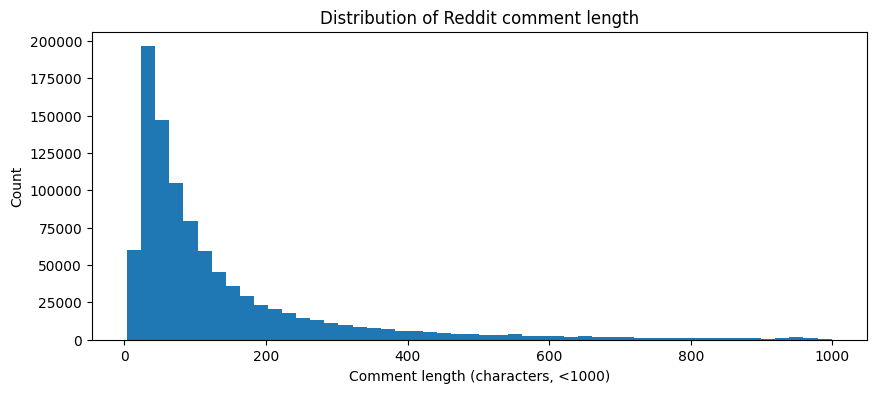

In [13]:
# Text length distribution (zoomed to avoid outlier squash)
plt.figure(figsize=(10, 4))
plt.hist(df[df['text_len'] < 1000]['text_len'], bins=50)
plt.xlabel('Comment length (characters, <1000)')
plt.ylabel('Count')
plt.title('Distribution of Reddit comment length')
plt.show()

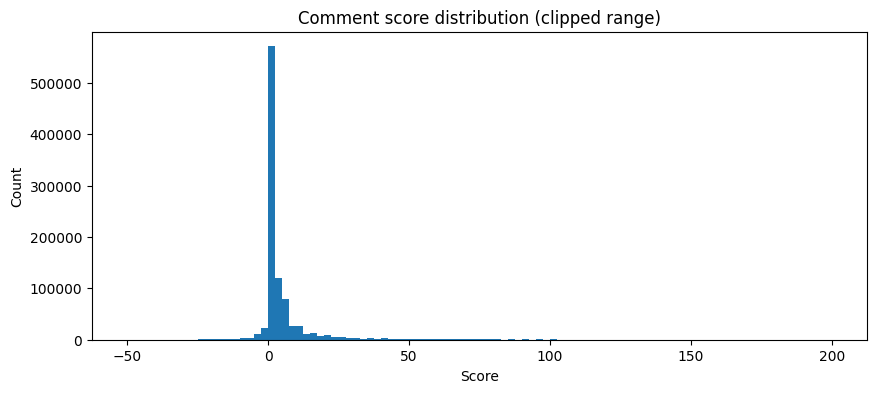

In [14]:
# Score distribution — heavily skewed usually, so log scale helps
plt.figure(figsize=(10, 4))
plt.hist(df['score'], bins=100, range=(-50, 200))
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Comment score distribution (clipped range)')
plt.show()

controversiality
0    948437
1     29552
Name: count, dtype: int64


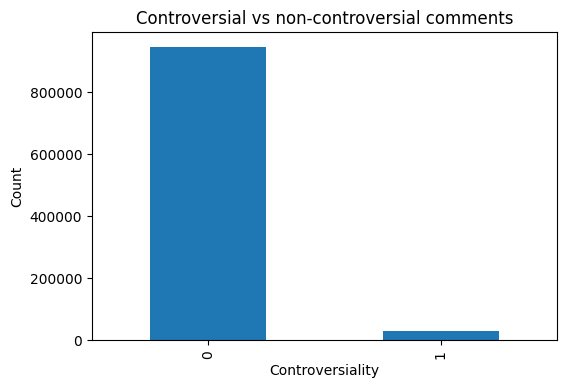

In [15]:
# Controversiality — likely mostly 0/1, check the split
print(df['controversiality'].value_counts())

df['controversiality'].value_counts().plot(kind='bar', figsize=(6,4))
plt.xlabel('Controversiality')
plt.ylabel('Count')
plt.title('Controversial vs non-controversial comments')
plt.show()